# M1 — Analiza dataseta (EDA)

**Tema 28 — Simulacija autonomnog vozila (Unity ML-Agents)**

Ovaj notebook ide **korak po korak**. Uz svaku ćeliju ide objašnjenje: *šta* radimo i *zašto*. Cilj M1:

1. **Provjeriti format** dataseta i **dokazati šta je koja kolona** (dataset nema header).
2. Izračunati **statistiku** vožnje (steering, brzina, glatkoća).
3. Prilagoditi **teoretsku raspodjelu** steeringu i testirati je (χ²).
4. Izvesti **konkretne brojeve** za Unity (§4.4/§4.5 u DESIGN.md).

Dataset: Udacity self-driving-car simulator (`zaynena/selfdriving-car-simulator`), lokalno pod `dataset/` (nije u gitu).

## Mali pojmovnik (za svaki slučaj)

- **Dataset bez headera** — CSV nema prvi red sa imenima kolona; sami moramo znati koja je koja.
- **steering** — ugao volana, ~[-1, 1]; negativno = lijevo, 0 = pravo, pozitivno = desno.
- **integritet** — svaki red ima svoje 3 slike na disku (`redova × 3 == slika`).
- **fingerprint (otisak)** — statistika kolone (min, max, % neg, % nula) iz koje *zaključimo* šta je.
- **deskriptivna statistika** — sažetak uzorka: sredina (mean), disperzija (varijansa), min/max, percentili.
- **disperzija (varijansa)** — koliko su vrijednosti raširene oko sredine (veće = raštrkanije).
- **percentil P95** — vrijednost ispod koje je 95% podataka.
- **Δsteering** — promjena volana od reda do reda; mjeri glatkoću (mali Δ = glatko).
- **raspodjela / fit** — teoretska kriva (npr. normalna) prilagođena obliku podataka.
- **χ² test saglasnosti** — brojka + odluka: da li kriva dobro opisuje podatke (prihvati/odbaci).
- **KS test** — druga provjera istog, bez binova; **D** = najveći razmak stvarne i teoretske krive.
- **zero-inflation** — gomila tačno-nula vrijednosti (kod nas: prava vožnja, steering=0).

## Priprema

Učitavamo naš paket `python/eda` i biblioteke za crtanje. `sys.path` red osigurava da notebook nađe paket bez obzira odakle je pokrenut.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
REPO_ROOT = next(p for p in [_here, *_here.parents] if (p / "python" / "eda").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from python.eda import config
from python.eda.loader import load_track, check_integrity
from python.eda.fingerprint import column_fingerprints
from python.eda import stats as eda_stats

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
print("Repo root:", REPO_ROOT)

Repo root: C:\Users\User\Development\RMS


# Sekcija 1 — Format i identitet kolona

## Korak 1 — Učitaj podatke

Tri izvora: `track1` (lakša staza), `track2` (teža, planinska), `combined` (obje spojene). Primarno analiziramo **combined**. CSV je bez headera, pa mu `load_track` sam dodijeli imena kolona (koja dokazujemo u Koraku 3).

In [2]:
ds = load_track("combined")
print(f"Oblik tabele: {ds.df.shape[0]:,} redova x {ds.df.shape[1]} kolona")
ds.df.head()

Oblik tabele: 32,443 redova x 7 kolona


,center,left,right,steering,throttle,brake,speed
0,Desktop\track1data\IMG\center_2019_04_02_19_25...,Desktop\track1data\IMG\left_2019_04_02_19_25_3...,Desktop\track1data\IMG\right_2019_04_02_19_25_...,0.0,0.000000,0.0,0.000011
1,Desktop\track1data\IMG\center_2019_04_02_19_25...,Desktop\track1data\IMG\left_2019_04_02_19_25_3...,Desktop\track1data\IMG\right_2019_04_02_19_25_...,0.0,0.000000,0.0,0.000007
2,Desktop\track1data\IMG\center_2019_04_02_19_25...,Desktop\track1data\IMG\left_2019_04_02_19_25_3...,Desktop\track1data\IMG\right_2019_04_02_19_25_...,0.0,0.000000,0.0,0.000003
3,Desktop\track1data\IMG\center_2019_04_02_19_25...,Desktop\track1data\IMG\left_2019_04_02_19_25_3...,Desktop\track1data\IMG\right_2019_04_02_19_25_...,0.0,0.048016,0.0,0.002267
4,Desktop\track1data\IMG\center_2019_04_02_19_25...,Desktop\track1data\IMG\left_2019_04_02_19_25_3...,Desktop\track1data\IMG\right_2019_04_02_19_25_...,0.0,0.281203,0.0,0.175589


Prve tri kolone su **putanje slika** (`Desktop\...\IMG\...`), zadnje četiri su **brojevi**. Putanje su sa tuđe mašine — svodimo ih na ime fajla + lokalni `IMG/` folder.

## Korak 2 — Provjera integriteta

Svaki red mora imati svoje 3 slike, pa `redova × 3 == broj .jpg u IMG/`. `unresolved_rows` broji redove kojima fali slika. Ovo je **kapija M1**.

In [3]:
for name in ("track1", "track2", "combined"):
    print(check_integrity(load_track(name)).summary())

[track1] rows=10,615 images=31,845 expected=31,845 -> OK; unresolved_rows=0 (sample 0/500)


[track2] rows=21,828 images=65,484 expected=65,484 -> OK; unresolved_rows=0 (sample 0/500)


[combined] rows=32,443 images=97,329 expected=97,329 -> OK; unresolved_rows=0 (sample 0/500)


## Korak 3 — Šta je koja kolona? (dokaz, ne pretpostavka)

Bez headera **ne vjerujemo naslijepo** redoslijedu. Gledamo otisak svake brojčane kolone:

- **steering** — jedina ide u minus (volan lijevo).
- **speed** — nenegativna, ali velike vrijednosti (preko 1).
- **brake** — [0,1] kolona koja je skoro sva nula.
- **throttle** — preostala [0,1] kolona sa pozitivnim vrijednostima.

`slaze se = True` znači zaključak iz statistike = pretpostavljeno ime (Udacity redoslijed potvrđen).

In [4]:
fps = column_fingerprints(ds)
fp_table = pd.DataFrame(
    [
        {
            "kolona": fp.column_index,
            "pretpostavka": fp.assumed_name,
            "zakljucak": fp.inferred_identity,
            "min": round(fp.minimum, 3),
            "max": round(fp.maximum, 3),
            "% neg": round(fp.pct_negative, 1),
            "% nula": round(fp.pct_zero, 1),
            "slaze se": fp.matches_assumption,
        }
        for fp in fps
    ]
)
fp_table

,kolona,pretpostavka,zakljucak,min,max,% neg,% nula,slaze se
0,4,steering,steering,-1.0,1.000,23.5,58.6,True
1,5,throttle,throttle,0.0,1.000,0.0,50.6,True
2,6,brake,brake,0.0,1.000,0.0,94.6,True
3,7,speed,speed,0.0,21.949,0.0,0.0,True


### Vizuelni dokaz (dva panela)

Lijevo: **% negativnih i % nula** — *steering* jedini negativan, *brake* skoro sve nule. Ali speed po tome izgleda prazan (ni negativan, ni nula), pa desno crtamo **raspon (max)** — tu speed "iskoči" (velika magnituda). Svaka kolona prepoznata po SVOJOJ osobini.

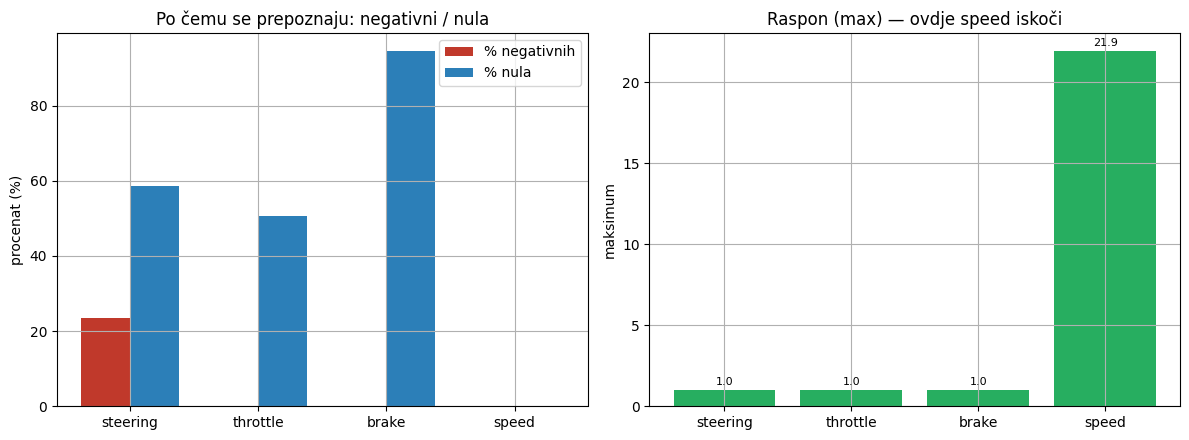

In [5]:
labels = [fp.inferred_identity for fp in fps]
pct_neg = [fp.pct_negative for fp in fps]
pct_zero = [fp.pct_zero for fp in fps]
maxes = [fp.maximum for fp in fps]
x = np.arange(len(labels))
w = 0.38

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))
axL.bar(x - w / 2, pct_neg, w, label="% negativnih", color="#c0392b")
axL.bar(x + w / 2, pct_zero, w, label="% nula", color="#2c7fb8")
axL.set_xticks(x); axL.set_xticklabels(labels); axL.set_ylabel("procenat (%)")
axL.set_title("Po čemu se prepoznaju: negativni / nula"); axL.legend()

axR.bar(x, maxes, color="#27ae60")
axR.set_xticks(x); axR.set_xticklabels(labels); axR.set_ylabel("maksimum")
axR.set_title("Raspon (max) — ovdje speed iskoči")
for i, m in enumerate(maxes):
    axR.text(i, m + 0.3, f"{m:.1f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

# Sekcija 2 — Deskriptivna statistika

## Korak 4 — Sažetak brojeva

Za tri veličine računamo: obim uzorka, **sredinu** (matematičko očekivanje), **disperziju** (varijansu) i **std**, min/max i percentile.

- **steering** — stil vožnje.
- **speed** — brzina.
- **|Δsteering|** — glatkoća: koliko se volan trza. **Računa se po stazi** (nikad preko spoja track1→track2), da ne izmislimo lažan skok.

In [6]:
t1, t2 = load_track("track1"), load_track("track2")
abs_delta = eda_stats.abs_delta_steering([t1, t2])  # po stazi, pa spojeno

summaries = {
    "steering": eda_stats.describe(ds.df["steering"], "steering"),
    "speed": eda_stats.describe(ds.df["speed"], "speed"),
    "|delta steering|": eda_stats.describe(abs_delta, "|delta steering|"),
}
desc_table = pd.DataFrame(
    [
        {
            "varijabla": s.variable,
            "n": s.n,
            "mean": round(s.mean, 4),
            "disperzija": round(s.variance, 4),
            "std": round(s.std, 4),
            "min": round(s.minimum, 3),
            "max": round(s.maximum, 3),
            "P50": round(s.percentiles[50], 3),
            "P95": round(s.percentiles[95], 3),
            "P99": round(s.percentiles[99], 3),
        }
        for s in summaries.values()
    ]
)
desc_table

,varijabla,n,mean,disperzija,std,min,max,P50,P95,P99
0,steering,32443,-0.0209,0.1515,0.3892,-1.0,1.000,0.00,0.800,1.000
1,speed,32443,10.2114,10.6855,3.2689,0.0,21.949,10.25,15.275,17.486
2,|delta steering|,32441,0.1112,0.0385,0.1963,0.0,1.000,0.00,0.550,1.000


## Korak 5 — Histogrami

Histogram = slika raspodjele (gdje se podaci gomilaju). Na |Δsteering| crtamo i **P95 liniju** = prag iznad kojeg je promjena volana "nagla" (ide u reward, DESIGN §4.5). Rep je dug pa koristimo log skalu da bude vidljiv.

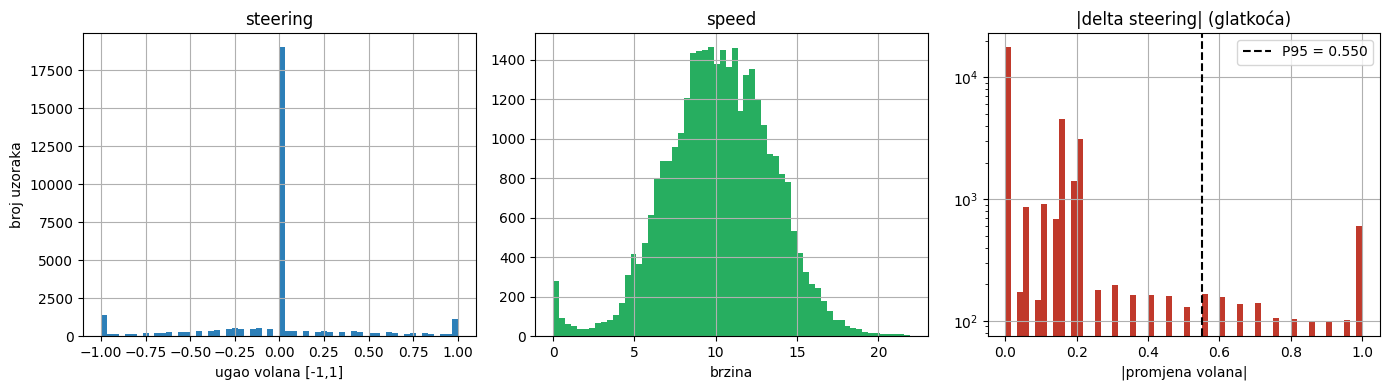

Prag nagle promjene volana (P95 od |delta steering|): 0.550


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(ds.df["steering"], bins=60, color="#2c7fb8")
axes[0].set_title("steering"); axes[0].set_xlabel("ugao volana [-1,1]"); axes[0].set_ylabel("broj uzoraka")

axes[1].hist(ds.df["speed"], bins=60, color="#27ae60")
axes[1].set_title("speed"); axes[1].set_xlabel("brzina")

p95 = np.percentile(abs_delta, config.DELTA_STEERING_PERCENTILE)
axes[2].hist(abs_delta, bins=60, color="#c0392b")
axes[2].axvline(p95, color="black", linestyle="--", label=f"P95 = {p95:.3f}")
axes[2].set_title("|delta steering| (glatkoća)"); axes[2].set_xlabel("|promjena volana|"); axes[2].legend()
axes[2].set_yscale("log")
plt.tight_layout(); plt.show()
print(f"Prag nagle promjene volana (P95 od |delta steering|): {p95:.3f}")

## Korak 6 — track1 vs track2

track1 je ravna (lakša), track2 planinska (oštre krivine). Očekujemo da track2 ima **širi** steering (više punog zaokreta).

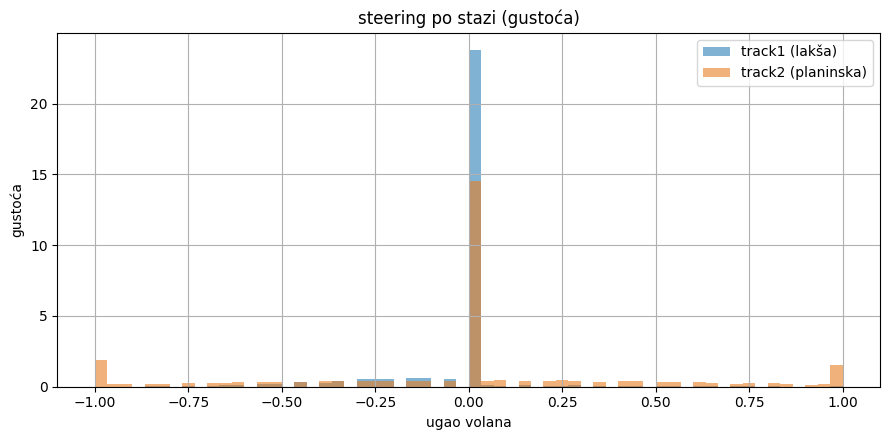

track1: std=0.155  P95=0.000  udio nula=79.3%
track2: std=0.462  P95=1.000  udio nula=48.4%


In [8]:
fig, ax = plt.subplots()
ax.hist(t1.df["steering"], bins=60, alpha=0.6, density=True, label="track1 (lakša)", color="#2c7fb8")
ax.hist(t2.df["steering"], bins=60, alpha=0.6, density=True, label="track2 (planinska)", color="#e67e22")
ax.set_title("steering po stazi (gustoća)"); ax.set_xlabel("ugao volana"); ax.set_ylabel("gustoća"); ax.legend()
plt.tight_layout(); plt.show()
for nm, tds in (("track1", t1), ("track2", t2)):
    s = eda_stats.describe(tds.df["steering"], nm)
    zero_pct = (tds.df['steering'] == 0).mean() * 100
    print(f"{nm}: std={s.std:.3f}  P95={s.percentiles[95]:.3f}  udio nula={zero_pct:.1f}%")

# Sekcija 3 — Prilagođavanje raspodjele + χ² test

## Korak 7 — Fit + test saglasnosti

Pitanje: da li ljudski steering prati neku poznatu raspodjelu? Postupak (kao na predavanju):

1. **Zero-inflation:** velik dio steeringa je *tačno 0* (prava vožnja). To brojimo posebno (`zero_mass`) i fitujemo **oblik ne-nula pokreta** (kad se stварно okreće volan).
2. **Fit** tri kandidata (normalna, laplace, uniformna) na ne-nula tijelo.
3. **Rangiraj** po AIC (manji = bolji).
4. **Testiraj** pobjednika χ² testom (+ KS provjera). χ² > kritično → **odbaci** (ne fituje).

Napomena: rezultat *može* biti "odbaci" — i to je validan nalaz (formalno pokazuje da podaci ne prate standardnu krivu).

In [9]:
res = eda_stats.fit_steering(ds.df["steering"])
print(f"Udio tačno-nula steeringa (prava vožnja): {res.zero_mass*100:.1f}%")
print()
aic_table = pd.DataFrame(
    [{"raspodjela": k, "AIC (manji=bolji)": round(v, 0)} for k, v in res.aic_ranking.items()]
).sort_values("AIC (manji=bolji)").reset_index(drop=True)
print("AIC rangiranje (na ne-nula tijelu):")
print(aic_table.to_string(index=False))
print()
print(f"Pobjednik po AIC: {res.dist_name}  params={tuple(round(p,4) for p in res.params)}")
print(f"chi2 test: stat={res.chi2_stat:.1f}  dof={res.dof}  kriticno={res.chi2_critical:.1f}  p={res.chi2_pvalue:.3g}")
print(f"Odluka:    {'ODBACI (ne fituje)' if res.reject_null else 'PRIHVATI (fituje)'} na alpha={res.alpha}")
print(f"KS test:   D={res.ks_stat:.4f}  p={res.ks_pvalue:.3g}")

Udio tačno-nula steeringa (prava vožnja): 58.6%

AIC rangiranje (na ne-nula tijelu):
raspodjela  AIC (manji=bolji)
   uniform            18644.0
      norm            24574.0
   laplace            26944.0

Pobjednik po AIC: uniform  params=(-1.0, 2.0)
chi2 test: stat=6717.6  dof=27  kriticno=40.1  p=0
Odluka:    ODBACI (ne fituje) na alpha=0.05
KS test:   D=0.1019  p=5.59e-122


## Korak 8 — Vizuelno: podaci vs fitovane krive

Histogram ne-nula steeringa (gustoća) + sve tri fitovane krive preko njega. Vidi se koliko (ne) prate stварни oblik.

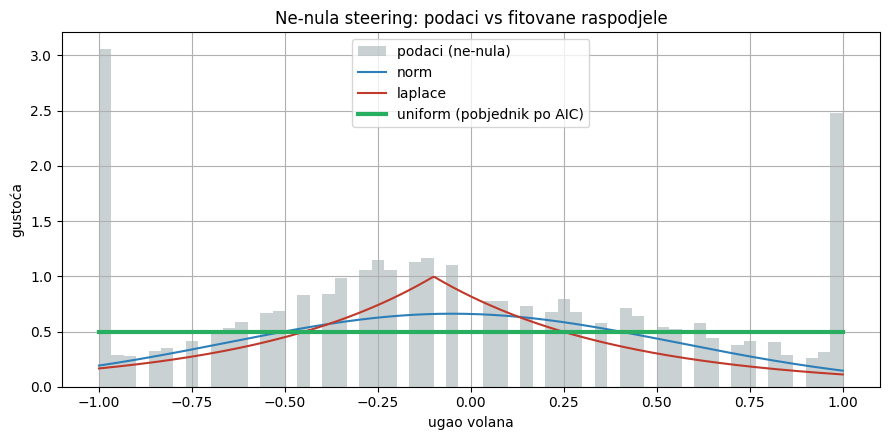

In [10]:
body = ds.df["steering"].to_numpy()
body = body[body != 0.0]
xg = np.linspace(-1, 1, 400)

fig, ax = plt.subplots()
ax.hist(body, bins=60, density=True, alpha=0.5, color="#95a5a6", label="podaci (ne-nula)")
colors = {"norm": "#2c7fb8", "laplace": "#c0392b", "uniform": "#27ae60"}
for name in config.STEERING_FIT_CANDIDATES:
    dist = getattr(sp_stats, name)
    params = dist.fit(body)
    lw = 3 if name == res.dist_name else 1.5
    tag = " (pobjednik po AIC)" if name == res.dist_name else ""
    ax.plot(xg, dist.pdf(xg, *params), color=colors[name], lw=lw, label=name + tag)
ax.set_title("Ne-nula steering: podaci vs fitovane raspodjele")
ax.set_xlabel("ugao volana"); ax.set_ylabel("gustoća"); ax.legend()
plt.tight_layout(); plt.show()

## Zaključak M1 (dosad)

- **Format i kolone** potvrđeni statistički (Sekcija 1).
- **Deskriptivna statistika**: steering centriran oko 0, dominira prava vožnja; track2 ima širi steering od track1.
- **Raspodjela**: steering je **zero-inflated** (velik udio tačnih nula) + zasićenje na ±1 (puni zaokret). χ² **odbacuje** standardne raspodjele — ljudski steering ne prati jednostavnu krivu; koristimo **empirijsku raspodjelu** kao referencu (baš to poredimo sa RL/BC agentima u M5).
- **Kalibracija za Unity** (DESIGN §4.4/§4.5): raspon steeringa, prag |Δsteering| (P95), tipičan raspon brzine — izvlačimo u sljedećem koraku (US3).

> Taksonomija za odbranu: model je stohastički, kontinualnih stanja, diskretnog vremena, agentski — a steering je nedeterministička veličina koju smo statistički okarakterizovali.